# Day 1 — Exploratory Data Analysis
## Healthcare Fraud Detection
**UGASS DSC x Zindi Capstone**

---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# --- FILE PATHS (already set for your machine) ---
CSV_PATH   = r'C:\Users\Ferdinard\Desktop\CODES\mlp\data\healthcare_fraud_detection.csv'
PLOTS_DIR  = r'C:\Users\Ferdinard\Desktop\CODES\mlp\plots'

# Create plots folder automatically if it doesn't exist
os.makedirs(PLOTS_DIR, exist_ok=True)

# Load data
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
df.head()

Shape: (10000, 20)


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


---
## 2. Basic Info & Summary Stats

In [2]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

In [3]:
# Summary statistics for numerical columns
df.describe().round(2)

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,9650.00
mean,49.76,86905.21,572.80,475.51,14.41,68.63,0.08,2.20,0.29,3.03
std,17.91,14965.32,406.20,323.26,8.49,14.91,0.28,1.71,0.45,1.72
min,1.00,36415.00,60.21,50.35,0.00,42.00,0.00,0.00,0.00,0.00
25%,37.75,80053.00,305.20,257.20,7.00,60.00,0.00,1.00,0.00,2.00
50%,50.00,93000.00,461.22,388.37,14.00,66.00,0.00,2.00,0.00,3.00
75%,62.00,99213.00,711.36,598.35,22.00,72.00,0.00,3.00,1.00,4.00
max,95.00,99214.00,6590.70,4270.89,29.00,144.00,1.00,5.00,1.00,12.00


In [4]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
print(f'\nTotal missing: {missing.sum()} rows ({missing.sum()/len(df)*100:.1f}% of dataset)')

Columns with missing values:
Insurance_Type        350
Provider_Specialty    350
Prior_Visits_12m      350
dtype: int64

Total missing: 1050 rows (10.5% of dataset)


---
## 3. Plot 1 — Target Distribution (Class Imbalance)

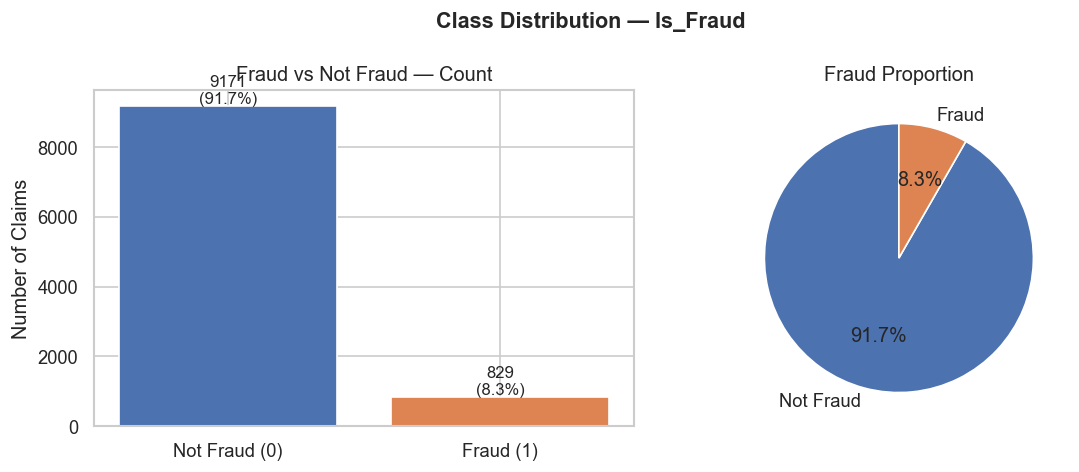


⚠ IMBALANCED DATASET: Only 8.3% of claims are fraudulent.
→ Do NOT rely on accuracy. Use F1-Score and ROC-AUC instead.
→ Use class_weight="balanced" or SMOTE during modeling.


In [5]:
fraud_counts = df['Is_Fraud'].value_counts()
fraud_pct    = df['Is_Fraud'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Fraud vs Not Fraud — Count')
axes[0].set_ylabel('Number of Claims')
for i, (count, pct) in enumerate(zip(fraud_counts, fraud_pct)):
    axes[0].text(i, count + 80, f'{count}\n({pct:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(fraud_counts, labels=['Not Fraud', 'Fraud'], autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Fraud Proportion')

plt.suptitle('Class Distribution — Is_Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot1_class_distribution.png'), bbox_inches='tight')
plt.show()

print('\n⚠ IMBALANCED DATASET: Only 8.3% of claims are fraudulent.')
print('→ Do NOT rely on accuracy. Use F1-Score and ROC-AUC instead.')
print('→ Use class_weight="balanced" or SMOTE during modeling.')

---
## 4. Plot 2 — Claim Amount Distribution by Fraud Label

C:\Users\Ferdinard\AppData\Local\Temp\ipykernel_17460\1223094974.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


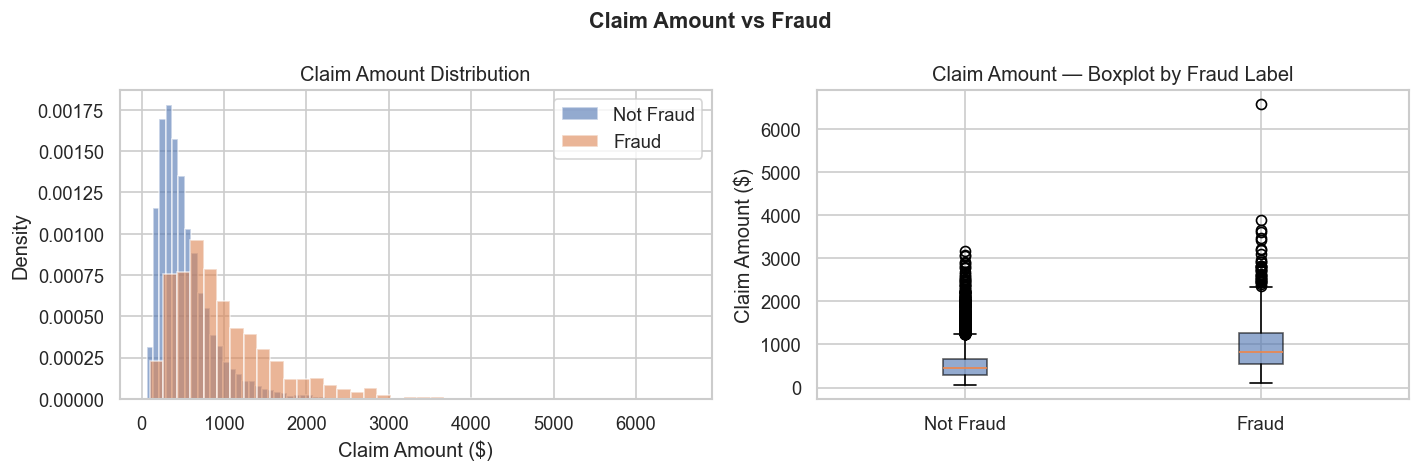

Mean Claim Amount:
Is_Fraud
Not Fraud    535.01
Fraud        990.93
Name: Claim_Amount, dtype: float64

→ Fraudulent claims average nearly 2x higher than legitimate claims.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overlapping histogram
for fraud_label, color, label in [(0, '#4C72B0', 'Not Fraud'), (1, '#DD8452', 'Fraud')]:
    subset = df[df['Is_Fraud'] == fraud_label]['Claim_Amount']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('Claim Amount Distribution')
axes[0].set_xlabel('Claim Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot
axes[1].boxplot(
    [df[df['Is_Fraud']==0]['Claim_Amount'], df[df['Is_Fraud']==1]['Claim_Amount']],
    labels=['Not Fraud', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='#4C72B0', alpha=0.6)
)
axes[1].set_title('Claim Amount — Boxplot by Fraud Label')
axes[1].set_ylabel('Claim Amount ($)')

plt.suptitle('Claim Amount vs Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot2_claim_amount.png'), bbox_inches='tight')
plt.show()

print('Mean Claim Amount:')
print(df.groupby('Is_Fraud')['Claim_Amount'].mean().rename({0: 'Not Fraud', 1: 'Fraud'}).round(2))
print('\n→ Fraudulent claims average nearly 2x higher than legitimate claims.')

---
## 5. Plot 3 — Correlation Matrix

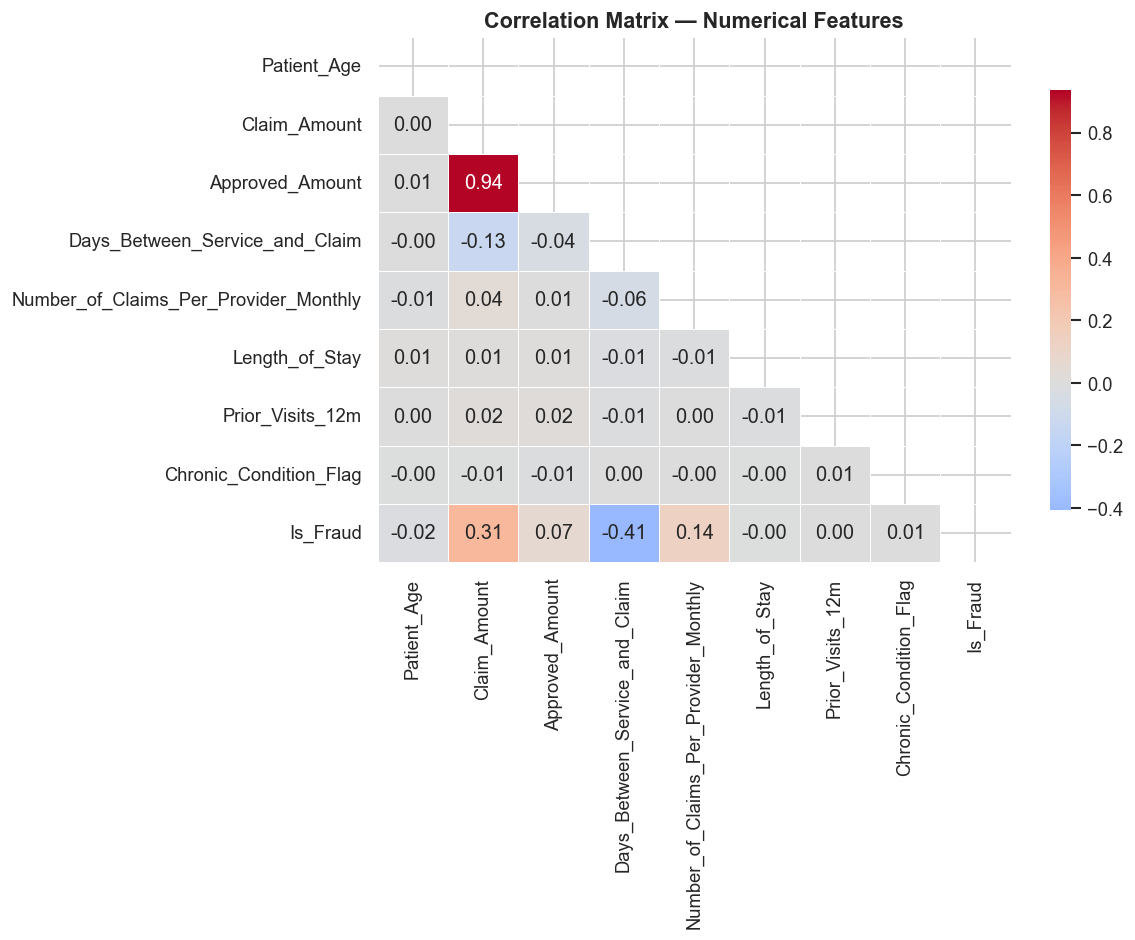

Feature correlations with Is_Fraud (sorted by strength):
Days_Between_Service_and_Claim          -0.405
Claim_Amount                             0.309
Number_of_Claims_Per_Provider_Monthly    0.136
Approved_Amount                          0.065
Patient_Age                             -0.017
Chronic_Condition_Flag                   0.009
Length_of_Stay                          -0.002
Prior_Visits_12m                         0.001
Name: Is_Fraud, dtype: float64


In [7]:
numerical_cols = [
    'Patient_Age', 'Claim_Amount', 'Approved_Amount',
    'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly',
    'Length_of_Stay', 'Prior_Visits_12m', 'Chronic_Condition_Flag', 'Is_Fraud'
]

corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, center=0, ax=ax, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot3_correlation_matrix.png'), bbox_inches='tight')
plt.show()

fraud_corr = corr_matrix['Is_Fraud'].drop('Is_Fraud').sort_values(key=abs, ascending=False)
print('Feature correlations with Is_Fraud (sorted by strength):')
print(fraud_corr.round(3))

---
## 6. Plot 4 — Fraud Rate by Categorical Features

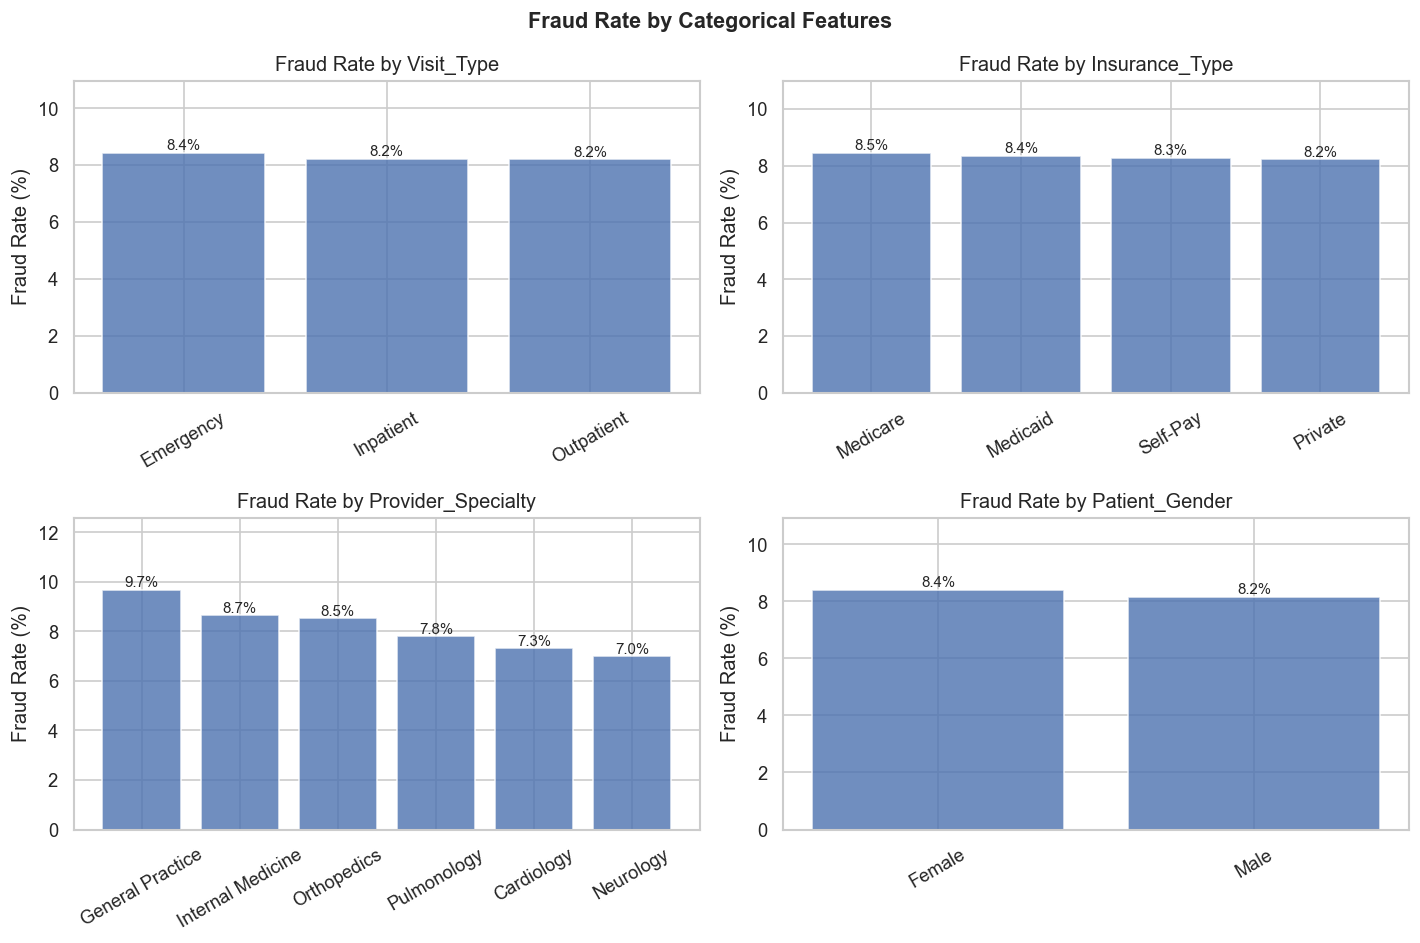

In [8]:
cat_cols = ['Visit_Type', 'Insurance_Type', 'Provider_Specialty', 'Patient_Gender']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)['Is_Fraud'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(fraud_rate.index, fraud_rate.values, color='#4C72B0', alpha=0.8)
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].set_ylim(0, fraud_rate.max() * 1.3)
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=9
        )

plt.suptitle('Fraud Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot4_fraud_by_category.png'), bbox_inches='tight')
plt.show()

---
## 7. Plot 5 — Provider-Level Analysis

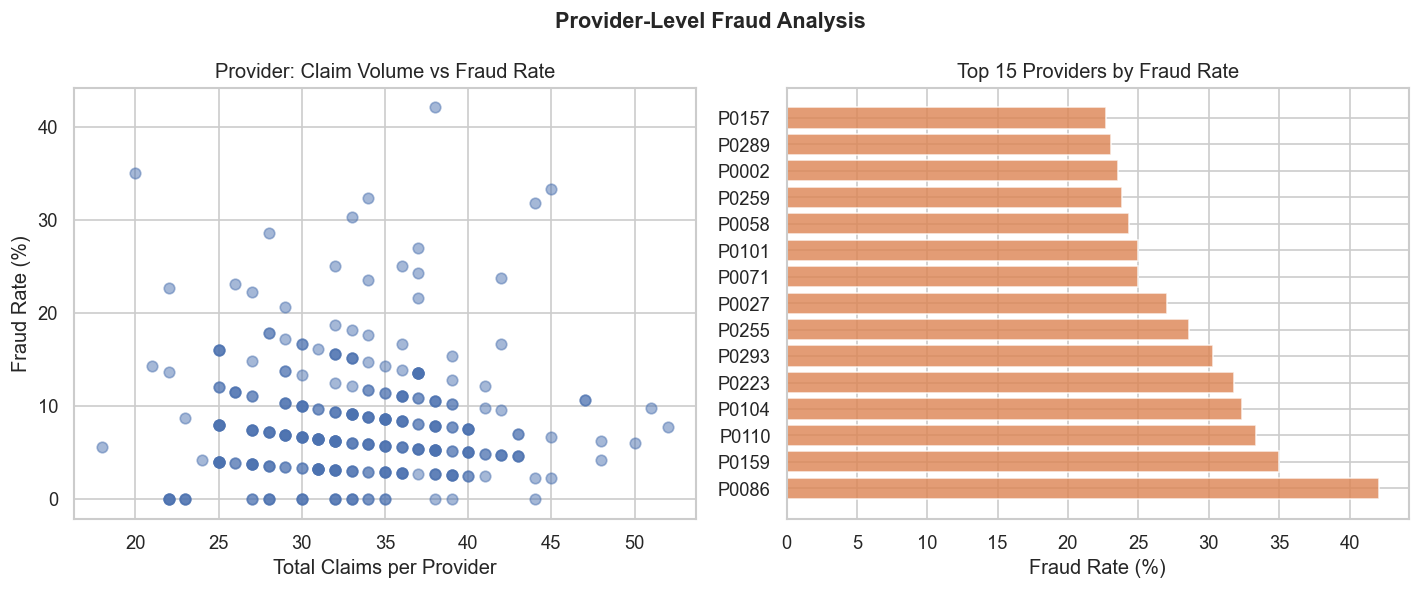

Providers with >20% fraud rate: 18
→ Provider_ID fraud rate will be a powerful engineered feature tomorrow.


In [9]:
provider_stats = df.groupby('Provider_ID').agg(
    total_claims=('Claim_ID', 'count'),
    fraud_rate=('Is_Fraud', 'mean'),
    avg_claim=('Claim_Amount', 'mean')
).reset_index()
provider_stats['fraud_rate_pct'] = provider_stats['fraud_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: claims volume vs fraud rate
axes[0].scatter(
    provider_stats['total_claims'],
    provider_stats['fraud_rate_pct'],
    alpha=0.5, color='#4C72B0', s=40
)
axes[0].set_xlabel('Total Claims per Provider')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Provider: Claim Volume vs Fraud Rate')

# Top 15 highest-fraud providers
top_fraud = provider_stats.nlargest(15, 'fraud_rate_pct')
axes[1].barh(top_fraud['Provider_ID'], top_fraud['fraud_rate_pct'], color='#DD8452', alpha=0.8)
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_title('Top 15 Providers by Fraud Rate')

plt.suptitle('Provider-Level Fraud Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot5_provider_analysis.png'), bbox_inches='tight')
plt.show()

print(f'Providers with >20% fraud rate: {(provider_stats["fraud_rate"] > 0.2).sum()}')
print('→ Provider_ID fraud rate will be a powerful engineered feature tomorrow.')

---
## 8. Day 1 Summary & Key Findings

In [10]:
print('=== DAY 1 EDA SUMMARY ===')
print(f'Dataset shape        : {df.shape}')
print(f'Fraud rate           : {df["Is_Fraud"].mean()*100:.1f}%  <- IMBALANCED')
print(f'Missing values in    : Insurance_Type, Provider_Specialty, Prior_Visits_12m')
print()
print('Top findings:')
print('  1. Fraudulent claims are ~2x higher in Claim_Amount')
print('  2. Claim_Amount is the strongest predictor of fraud')
print('  3. Provider-level fraud rates vary significantly')
print()
print('Tomorrow (Day 2):')
print('  - Fill missing values (mode for categoricals, median for numeric)')
print('  - One-Hot Encode: Insurance_Type, Visit_Type, Provider_Specialty, Patient_Gender')
print('  - Engineer features: provider_fraud_rate, claim_to_approved_ratio')
print('  - Scale: Claim_Amount, Approved_Amount, Prior_Visits_12m')
print()
print(f'Plots saved to: {PLOTS_DIR}')

=== DAY 1 EDA SUMMARY ===
Dataset shape        : (10000, 20)
Fraud rate           : 8.3%  <- IMBALANCED
Missing values in    : Insurance_Type, Provider_Specialty, Prior_Visits_12m

Top findings:
  1. Fraudulent claims are ~2x higher in Claim_Amount
  2. Claim_Amount is the strongest predictor of fraud
  3. Provider-level fraud rates vary significantly

Tomorrow (Day 2):
  - Fill missing values (mode for categoricals, median for numeric)
  - One-Hot Encode: Insurance_Type, Visit_Type, Provider_Specialty, Patient_Gender
  - Engineer features: provider_fraud_rate, claim_to_approved_ratio
  - Scale: Claim_Amount, Approved_Amount, Prior_Visits_12m

Plots saved to: C:\Users\Ferdinard\Desktop\CODES\mlp\plots
